# Regularization Yöntemleri: Ames Veri Seti Örneği

Bu dersin sonunda şunları yapabiliyor olmayı hedefliyoruz:

1. Lasso ve Ridge Regresyon yöntemlerini anlamak
2. Featurelara StandartScaling uygulamak ve bunun önemini kavramak
3. En iyi Regularization sonucunu elde etmek

## 1. Oluşturduğumuz Veri Setini Çağırma

In [1]:
import numpy as np
import pandas as pd
from pandas import Series, DataFrame
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso, LassoCV, Ridge, RidgeCV
from sklearn.metrics import r2_score
from joblib import dump, load
import warnings
warnings.filterwarnings(action='ignore')

In [2]:
ames = load('C:/Users/ataoz/Documents/GitHub/DSBootcampTürkçe/proje2/feature-engineering/data/ames_data.pkl')

In [3]:
ames

,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Gr Liv Area,Full Bath,Bedroom AbvGr,Kitchen AbvGr,Fireplaces,Garage Cars,OQ2,YB2,OQ_x_YB,OQ_/_LA,House Style,Neighborhood,SalePrice
0,31770,6,5,1960,1960,1656,1,3,1,2,2.0,36,3841600,11760,0.000189,1Story,NAmes,215000
1,11622,5,6,1961,1961,896,1,2,1,0,1.0,25,3845521,9805,0.000430,1Story,NAmes,105000
2,14267,6,6,1958,1958,1329,1,3,1,0,1.0,36,3833764,11748,0.000421,1Story,NAmes,172000
3,11160,7,5,1968,1968,2110,2,3,1,2,2.0,49,3873024,13776,0.000627,1Story,NAmes,244000
4,13830,5,5,1997,1998,1629,2,3,1,1,2.0,25,3988009,9985,0.000362,2Story,Gilbert,189900
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,7937,6,6,1984,1984,1003,1,3,1,0,2.0,36,3936256,11904,0.000756,SLvl,Mitchel,142500
2926,8885,5,5,1983,1983,902,1,2,1,0,2.0,25,3932289,9915,0.000563,1Story,Mitchel,131000
2927,10441,5,5,1992,1992,970,1,3,1,0,0.0,25,3968064,9960,0.000479,SFoyer,Mitchel,132000
2928,10010,5,5,1974,1975,1389,1,2,1,1,2.0,25,3896676,9870,0.000500,1Story,Mitchel,170000


In [4]:
ames = pd.get_dummies(ames, columns=['House Style','Neighborhood'], drop_first=True)
ames

,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Gr Liv Area,Full Bath,Bedroom AbvGr,Kitchen AbvGr,Fireplaces,...,Neighborhood_NridgHt,Neighborhood_OldTown,Neighborhood_Other,Neighborhood_SWISU,Neighborhood_Sawyer,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker
0,31770,6,5,1960,1960,1656,1,3,1,2,...,0,0,0,0,0,0,0,0,0,0
1,11622,5,6,1961,1961,896,1,2,1,0,...,0,0,0,0,0,0,0,0,0,0
2,14267,6,6,1958,1958,1329,1,3,1,0,...,0,0,0,0,0,0,0,0,0,0
3,11160,7,5,1968,1968,2110,2,3,1,2,...,0,0,0,0,0,0,0,0,0,0
4,13830,5,5,1997,1998,1629,2,3,1,1,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,7937,6,6,1984,1984,1003,1,3,1,0,...,0,0,0,0,0,0,0,0,0,0
2926,8885,5,5,1983,1983,902,1,2,1,0,...,0,0,0,0,0,0,0,0,0,0
2927,10441,5,5,1992,1992,970,1,3,1,0,...,0,0,0,0,0,0,0,0,0,0
2928,10010,5,5,1974,1975,1389,1,2,1,1,...,0,0,0,0,0,0,0,0,0,0


In [5]:
ames.columns

Index(['Lot Area', 'Overall Qual', 'Overall Cond', 'Year Built',
       'Year Remod/Add', 'Gr Liv Area', 'Full Bath', 'Bedroom AbvGr',
       'Kitchen AbvGr', 'Fireplaces', 'Garage Cars', 'OQ2', 'YB2', 'OQ_x_YB',
       'OQ_/_LA', 'SalePrice', 'House Style_1.5Unf', 'House Style_1Story',
       'House Style_2.5Fin', 'House Style_2.5Unf', 'House Style_2Story',
       'House Style_SFoyer', 'House Style_SLvl', 'Neighborhood_BrDale',
       'Neighborhood_BrkSide', 'Neighborhood_ClearCr', 'Neighborhood_CollgCr',
       'Neighborhood_Crawfor', 'Neighborhood_Edwards', 'Neighborhood_Gilbert',
       'Neighborhood_IDOTRR', 'Neighborhood_MeadowV', 'Neighborhood_Mitchel',
       'Neighborhood_NAmes', 'Neighborhood_NPkVill', 'Neighborhood_NWAmes',
       'Neighborhood_NoRidge', 'Neighborhood_NridgHt', 'Neighborhood_OldTown',
       'Neighborhood_Other', 'Neighborhood_SWISU', 'Neighborhood_Sawyer',
       'Neighborhood_SawyerW', 'Neighborhood_Somerst', 'Neighborhood_StoneBr',
       'Neighborhood_Ti

## 2. Modellemeye Hazırlık

In [6]:
X = ames.drop(columns=['SalePrice'])

y = ames['SalePrice']

In [7]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2790 entries, 0 to 2929
Data columns (total 46 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Lot Area              2790 non-null   int64  
 1   Overall Qual          2790 non-null   int64  
 2   Overall Cond          2790 non-null   int64  
 3   Year Built            2790 non-null   int64  
 4   Year Remod/Add        2790 non-null   int64  
 5   Gr Liv Area           2790 non-null   int64  
 6   Full Bath             2790 non-null   int64  
 7   Bedroom AbvGr         2790 non-null   int64  
 8   Kitchen AbvGr         2790 non-null   int64  
 9   Fireplaces            2790 non-null   int64  
 10  Garage Cars           2790 non-null   float64
 11  OQ2                   2790 non-null   int64  
 12  YB2                   2790 non-null   int64  
 13  OQ_x_YB               2790 non-null   int64  
 14  OQ_/_LA               2790 non-null   float64
 15  House Style_1.5Unf   

In [8]:
y

0       215000
1       105000
2       172000
3       244000
4       189900
         ...  
2925    142500
2926    131000
2927    132000
2928    170000
2929    188000
Name: SalePrice, Length: 2790, dtype: int64

- Modelimize girdi ve çıktı olarak vereceğimiz sütunları belirledikten sonra 2. aşamada, veri setini **train / validation / test** olarak 3'e bölmemiz gerekiyor. Bu işlemi yaparken de en yaygın bölme yaklaşımı olan **%60 / %20 / %20** 'yi kullanalım.

In [9]:
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.20,random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, random_state=43)

In [10]:
X_train.shape

(1674, 46)

In [11]:
X_val.shape

(558, 46)

In [12]:
X_test.shape

(558, 46)

- Artık modellerimizi oluşturmaya hazırız.

Eğer hatırlıyorsak, Feature Engineering işlemlerini konuştuğumuz notebookumuzun sonunda elde ettiğimiz en başarılı model sonucumuz **Test R^2 score was: 0.8982533931040323** şeklindeydi. Bakalım Regularization yöntemleri bu konuda bize ekstra bir fayda sağlayabilecekler mi?

## 3. Regularization Yöntemlerinin Davranış Tarzını Anlama

Modellerimize daha fazla parametre ekledikçe karmaşıklığı artar, ancak çok fazla parametre modelin öğrenilmesini zorlaştırır ve **Overfitting**'e neden olur. Ancak modelimizin karmaşıklığını azaltacağız derken, önemli featureları kaybedersek bu durum da **Underfitting**'e sebep olur.

- **Yani, modelimizde optimum bir nokta bulmamız gerekiyor**. 

Underfitting durumuyla baş etmek nispeten kolay. Çünkü buradaki sorun çok net ortada: **İyi bir model oluşturmak için elimizde yeterli veri yok**. Ancak, Overfitting durumuyla baş etmek için yapmamız gereken şey underfitting de olduğu kadar basit değil.

Temel olarak, Overfitting'in üstesinden gelmek için kullanılan 2 tane yöntem vardır; 
- **Model Karmaşıklığını Azaltmak**
- **Regularization Uygulamak**

Şu ana kadar öğrendiklerimizden yola çıkarsak, değişkenlerin eklenmesi, çıkarılması veya dönüştürülmesi gibi işlemler yaparak modelin performansını iyileştirmeye çalıştık. **(Tabiki ancak doğru işlemler yaptıysanız model performansında iyileşme görürsünüz :))** Ancak bu süreç özellikle büyük veri setlerinde oldukça yorucu olabiliyor. Keşke daha kesin bir yöntemi olsa bunun. İyi haber şu ki var :)

Regularize edilmiş Lineer Regresyon, **maliyet fonksiyonunu** değiştirerek bunu aşmaya çalışır. Basit Lineer Regresyonda, katsayılar yalnızca **Kare Hatalarının Toplamını(MSE)** en aza indirecek şekilde seçilir. Ancak regularize edilmiş Lineer Regresyonda, maliyet fonksiyonunun **katsayı değerlerini** cezalandıran ek bir bileşeni vardır.

> **SORU:** Peki, neden bir katsayıyı cezalandırma ihtiyacı hissedelim? 

En basit düzeyde, bir katsayıya sahip olan her bir değişkenin modelimiz üzerinde etkisi vardır. Ancak, büyük katsayılara göre, küçük katsayılara sahip olmak bizim için **daha basit, daha anlaşılır bir model** demektir. İşte Regularization, katsayıların daha dar bir bölge içinde yer alması için sınırlandırılması, model katsayılarını daha kararlı ve daha az aşırı hale getirme anlamına gelir.

Regularization, katsayıları ne kadar güçlü bir şekilde cezalandırmak istediğimizi söyleyen bir **regularization katsayısı** parametresi sunar. Bir uçta ceza yoktur ve bu durum zaten Basit Lineer Regresyon demektir. Ancak Diğer uçta ceza o kadar ağırdır ki, tüm katsayıları sıfıra indirgeriz. Bu iki uç arasında sürekli bir model seti vardır. **Validation** veya **Cross-Validation** ile en iyi değeri nasıl seçeceğimizi göreceğiz.

Regularization yöntemlerinin 2 ana çeşidi vardır. **LASSO**'da katsayıların mutlak değerlerinin toplamını, **RIDGE**'de ise katsayıların karelerinin toplamını cezalandırırız. Hangisinin daha iyi bir çözüm olduğu ise, modelimizin verilerine ve iş amacımıza bağlıdır. Şimdi bu yöntemleri daha detaylı inceleyelim.

### 3.1. Lasso Regresyonu



In [13]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1674 entries, 2325 to 912
Data columns (total 46 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Lot Area              1674 non-null   int64  
 1   Overall Qual          1674 non-null   int64  
 2   Overall Cond          1674 non-null   int64  
 3   Year Built            1674 non-null   int64  
 4   Year Remod/Add        1674 non-null   int64  
 5   Gr Liv Area           1674 non-null   int64  
 6   Full Bath             1674 non-null   int64  
 7   Bedroom AbvGr         1674 non-null   int64  
 8   Kitchen AbvGr         1674 non-null   int64  
 9   Fireplaces            1674 non-null   int64  
 10  Garage Cars           1674 non-null   float64
 11  OQ2                   1674 non-null   int64  
 12  YB2                   1674 non-null   int64  
 13  OQ_x_YB               1674 non-null   int64  
 14  OQ_/_LA               1674 non-null   float64
 15  House Style_1.5Unf 

In [14]:
lasso_model = Lasso(alpha = 10000)
lasso_model.fit(X_train, y_train)

Lasso(alpha=10000)

- Bakalım Lasso Regresyonu'nun model katsayılarına nasıl bir etkisi olmuş?

In [15]:
list(zip(X_train.columns, lasso_model.coef_))

[('Lot Area', 1.2123399400930956),
 ('Overall Qual', -0.0),
 ('Overall Cond', 0.0),
 ('Year Built', 0.0),
 ('Year Remod/Add', 232.86212948367006),
 ('Gr Liv Area', 47.44935631800879),
 ('Full Bath', -0.0),
 ('Bedroom AbvGr', -0.0),
 ('Kitchen AbvGr', -0.0),
 ('Fireplaces', 0.0),
 ('Garage Cars', 0.0),
 ('OQ2', 876.9923289734811),
 ('YB2', 0.10600053925839177),
 ('OQ_x_YB', 4.6315478756449036),
 ('OQ_/_LA', -0.0),
 ('House Style_1.5Unf', -0.0),
 ('House Style_1Story', 0.0),
 ('House Style_2.5Fin', -0.0),
 ('House Style_2.5Unf', -0.0),
 ('House Style_2Story', -0.0),
 ('House Style_SFoyer', 0.0),
 ('House Style_SLvl', -0.0),
 ('Neighborhood_BrDale', -0.0),
 ('Neighborhood_BrkSide', 0.0),
 ('Neighborhood_ClearCr', 0.0),
 ('Neighborhood_CollgCr', -0.0),
 ('Neighborhood_Crawfor', 0.0),
 ('Neighborhood_Edwards', -0.0),
 ('Neighborhood_Gilbert', -0.0),
 ('Neighborhood_IDOTRR', -0.0),
 ('Neighborhood_MeadowV', -0.0),
 ('Neighborhood_Mitchel', -0.0),
 ('Neighborhood_NAmes', 0.0),
 ('Neighborhood

### 3.2. Ridge Regresyonu

- Şimdi de Ridge Regresyonu tanımlayarak Lasso'yla arasındaki farkı anlamaya çalışalım.

In [16]:
ridge_model = Ridge(alpha = 1000000000000) # Bu çok yüksek bir regularization katsayısı! Genelde bu kadar yüksek sayılar kullanmayız
ridge_model.fit(X_train, y_train)

list(zip(X_train.columns, ridge_model.coef_))

[('Lot Area', 0.14449226194146794),
 ('Overall Qual', 6.03626733127465e-05),
 ('Overall Cond', 1.6827546659243524e-05),
 ('Year Built', 6.410072570697708e-05),
 ('Year Remod/Add', 0.0004900932165077403),
 ('Gr Liv Area', 0.02494197124620177),
 ('Full Bath', 1.6575766429650966e-05),
 ('Bedroom AbvGr', 1.6723384133121676e-05),
 ('Kitchen AbvGr', -1.1553376705909419e-06),
 ('Fireplaces', 2.4018597636384225e-05),
 ('Garage Cars', 2.511950594768206e-05),
 ('OQ2', 0.0007505233335103335),
 ('YB2', 0.2773820545834236),
 ('OQ_x_YB', 0.11964743487588132),
 ('OQ_/_LA', -6.688480211968633e-09),
 ('House Style_1.5Unf', -2.920142999937655e-07),
 ('House Style_1Story', -5.372400937719489e-06),
 ('House Style_2.5Fin', 2.2011759266669904e-07),
 ('House Style_2.5Unf', 9.367963035005872e-07),
 ('House Style_2Story', 6.460208551481876e-06),
 ('House Style_SFoyer', -1.82768368217826e-06),
 ('House Style_SLvl', -9.097297096141227e-07),
 ('Neighborhood_BrDale', -9.548473292410927e-07),
 ('Neighborhood_BrkSid

> **SORU**: Yöntemler arasındaki farkı anlayabildik mi?

**Ridge** tüm katsayıları yumuşatmış gibi duruyor, ve neredeyse 0'a kadar yaklaştırmasına rağmen dikkat edin aslında hiçbiri 0 değil!

Buna karşın **Lasso** birçok katsayının değerini 0'a eşitlemiş. İşte Lasso'yla Ridge arasındaki temel fark!

> **SORU:** Ancak hala Lasso'nun sıfırlamadığı bazı katsayılar var. Peki, hangi featureların katsayılarını sıfırlamamış dikkat ettiniz mi?

**LASSO**:
* **_Artı_**: Özellikle en önemli olan featurelara odaklanıp model karmaşıklığını azaltmada çok iyi.
* **_Eksi_**: Gerçekten yararlı olan featureları kaçırma riski var. (Alpha parametresinin önemi)

**Ridge**:
* **_Artı_**: Çoklu doğrusallığı sorunsuz bir şekilde işlemek için harika, önem dereceleri benzer featurelarla çalışırken çok iyi.
* **_Eksi_**: Featureları hiçbir zaman tam olarak atmaz. (Modele karmaşıklıktan başka bişey sağlamayan featurelarda bile)

Her zaman olduğu gibi, ikisi arasında seçim yapmak için validation yapmamız gerekir. Hedefimize ulaşmaya çalışmak gerçekten yalnızca birkaç temel özelliğe bağlıysa, Lasso daha iyi performans göstermelidir. Bunun yerine hedef birçok özelliğe bağlı ise (sadece biraz bağımlı olsa bile), Ridge'in daha iyi performans göstermesini bekleriz.

In [17]:
test_set_pred = lasso_model.predict(X_test)

In [18]:
print('R^2 of Lasso Model:', r2_score(y_test, test_set_pred))

R^2 of Lasso Model: 0.8220197556293333


In [19]:
test_set_pred2 = ridge_model.predict(X_test)

In [20]:
print('R^2 of Ridge Model:', r2_score(y_test, test_set_pred2))

R^2 of Ridge Model: 0.3732615329387079


> **SORU:** Lasso modelimiz çok daha iyi bir R<sup>2</sup> değeri getirdiğine göre veri setimizle ilgili nasıl bir yorum yapabiliriz?

### 3.3. Standard-Scaling (Regularization Yaparken Olmazsa Olmaz!)

Regularization'la ile ilgili büyük bir sorun, bir katsayının boyutunun ilişkinin gerçek gücünden ziyade ilişkili değişkenin birimlerini veya ölçeğini daha fazla yansıtabilmesidir. 

- Örneğin, bir mesafe milimetre cinsinden ölçülürse, metre cinsinden ölçülenden daha büyük bir katsayıya sahip olacaktır. Yani, elmayla elmayı kıyaslamak lazım. Başka bir şeyi değil! 

Bu nedenle en iyi uygulama, Regularization çalıştırmadan önce değişkenleri **standartlaştırmaktır**. Standartlaştırma, her bir özellik sütununun ortalamasını çıkarmak ve ardından standart sapmasına bölmek anlamına gelir. Bu, değişkenlerin birbirlerine göre daha adil bir şekilde cezalandırılmasını sağlar. Peki bunu nasıl yapabiliriz hadi şimdi ona bakalım.

In [21]:
from sklearn.preprocessing import StandardScaler

In [22]:
std_scale = StandardScaler()
std_scale.fit(X_train.values)

StandardScaler()

In [23]:
X_tr = std_scale.transform(X_train.values)

Featurelarımızı uygun şekilde ölçeklendirdiğimize göre, Lasso'yu daha önce olduğu gibi tekrardan uygulayabiliriz. 

> **NOT:** Değişkenler farklı ölçeklerde olduğu için daha önce yaptığımız teknik olarak iyi bir uygulama değildi. Bazı değişkenler (haksız yere) diğerlerinden daha fazla cezalandırılır.

In [24]:
lasso_model = Lasso(alpha = 10000)
lasso_model.fit(X_tr, y_train)

Lasso(alpha=10000)

In [25]:
list(zip(X_train.columns, lasso_model.coef_))

[('Lot Area', 0.0),
 ('Overall Qual', 0.0),
 ('Overall Cond', 0.0),
 ('Year Built', 0.0),
 ('Year Remod/Add', 1512.6643768963802),
 ('Gr Liv Area', 13979.311468500737),
 ('Full Bath', 0.0),
 ('Bedroom AbvGr', 0.0),
 ('Kitchen AbvGr', -0.0),
 ('Fireplaces', 1463.7975262548653),
 ('Garage Cars', 5143.209200972963),
 ('OQ2', 23166.37604063801),
 ('YB2', 5323.130819406681),
 ('OQ_x_YB', 0.0),
 ('OQ_/_LA', -0.0),
 ('House Style_1.5Unf', -0.0),
 ('House Style_1Story', 0.0),
 ('House Style_2.5Fin', -0.0),
 ('House Style_2.5Unf', -0.0),
 ('House Style_2Story', -0.0),
 ('House Style_SFoyer', -0.0),
 ('House Style_SLvl', -0.0),
 ('Neighborhood_BrDale', -0.0),
 ('Neighborhood_BrkSide', -0.0),
 ('Neighborhood_ClearCr', 0.0),
 ('Neighborhood_CollgCr', 0.0),
 ('Neighborhood_Crawfor', 0.0),
 ('Neighborhood_Edwards', -0.0),
 ('Neighborhood_Gilbert', -0.0),
 ('Neighborhood_IDOTRR', -0.0),
 ('Neighborhood_MeadowV', -0.0),
 ('Neighborhood_Mitchel', 0.0),
 ('Neighborhood_NAmes', -0.0),
 ('Neighborhood_NPk

- İlk Lasso modelimizle karşılaştırdığımızda gerçekten gereğinde fazla cezalandıralan featurelarımız varmış. Sadece hak edenleri ciddi bir şekilde cezalandırmak için Regularization yapmadan önce featurelarımıza **StandardScaler** uygulamayı unutmuyoruz :)

## 4. Regularization Yöntemindeki En İyi Alpha Parametresini Bulma

Bu aşamada, elimizdeki veri seti ve Lasso modeli için **en optimum regularization katsayının(alpha)** değerini bulmaya çalışacağız. 

İlk önce bir aday alpha değerlerimizi belirleyecek, ardından ise her bir aday değer için sırasıyla aşağıdaki adımları uygulayacağız:

1. Sürekli değişen alpha değerleriyle birlikte, eğitim verimizle Lasso modelimizi oluştaracak
2. Eğittiğimiz modelleri kullanarak validation verimizle elde ettiğimiz doğruluk değerlerine bakacağız

Ardından, farklı alpha değerleri için elde ettiğimiz hata miktarlarının nasıl değiştiğini bir görsel üzerinde çizdirecek ve alphanın validation verilerimizde hata metriğimizi nerede en aza indirdiğini göreceğiz. 

- İşte bu alpha değeri, son modelimiz için seçeceğimiz değer olacak.

In [26]:
from sklearn.pipeline import Pipeline

In [27]:
def mse(y_true, y_pred): # MSE parametresini tanımlama
    return np.mean((y_pred - y_true)**2) 

In [28]:
alphalist = 10**(np.linspace(-2,2,200)) # Daha geniş aralıkta inceleme yapmak için np.linspace() parametrelerini değiştirin
err_vec_val = np.zeros(len(alphalist))
err_vec_train = np.zeros(len(alphalist))

for index, curr_alpha in enumerate(alphalist):

    # Her bir döngüde ilk olarak Scaling uygula ve sonrasında belirtilen alpha değerinde Lasso'yu çalıştır
    steps = [('standardize', StandardScaler()),
             ('lasso', Lasso(alpha = curr_alpha))]

    pipe = Pipeline(steps)
    pipe.fit(X_train.values, y_train)

    val_set_pred = pipe.predict(X_val.values)
    err_vec_val[index] = mse(y_val, val_set_pred)

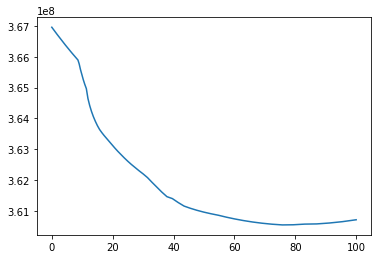

In [29]:
plt.plot(alphalist, err_vec_val);

In [30]:
np.min(err_vec_val) # Lasso kullanarak ulaşabildiğimiz minimum hata miktarı

360545419.6458587

In [31]:
alphalist[np.argmin(err_vec_val)] # Ulaştığımız minimum hata miktarına denk gelen alpha değeri

75.75250258771912

In [32]:
alphalist = 10**(np.linspace(-2,2,200)) # Daha geniş aralıkta inceleme yapmak için np.linspace() parametrelerini değiştirin
err_vec_val = np.zeros(len(alphalist))
err_vec_train = np.zeros(len(alphalist))

for index, curr_alpha in enumerate(alphalist):

    # Her bir döngüde ilk olarak Scaling uygula ve sonrasında belirtilen alpha değerinde Lasso'yu çalıştır
    steps = [('standardize', StandardScaler()),
             ('lasso', Lasso(alpha = curr_alpha))]

    pipe = Pipeline(steps)
    pipe.fit(X_train.values, y_train)

    val_set_pred = pipe.predict(X_val.values)
    err_vec_val[index] = r2_score(y_val, val_set_pred)

In [33]:
np.max(err_vec_val) # Lasso kullanarak ulaşabildiğimiz maximum R^2 değeri

0.8872088340275692

In [34]:
alphalist[np.argmax(err_vec_val)]

75.75250258771912